# Wine Quality Prediction

## Objective
Train and compare multiple classification models to predict the **quality of wine** based on its physicochemical properties, such as acidity, density, sulphates, and alcohol content.
The project aims to:
- Analyze the Wine Quality dataset and understand the distribution of quality scores.
- Perform Exploratory Data Analysis (EDA) on the physicochemical features.
- Identify relationships between chemical properties and wine quality using correlation analysis.
- Handle class imbalance in the quality classes.
- Transform wine quality scores into meaningful classification categories.
- Train and compare **Random Forest, Stochastic Gradient Descent (SGD), and Support Vector Classifier (SVC)** models.
- Evaluate the models using **accuracy, precision, recall, F1-score, classification reports, and confusion matrices**.
- Identify the most important features using the Random Forest model.
- Determine the best-performing model for predicting wine quality and recommend the most suitable model for deployment.

### Step 1: Import Libraries
Why?
Before working with data, we need Python libraries.
Pandas → Read and analyze datasets. NumPy → Mathematical calculations. Matplotlib → Basic graphs. Seaborn → Beautiful statistical graphs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

### Step 2: Load Dataset
Why? The dataset is stored as a CSV file. We use Pandas to load it.

In [2]:
df = pd.read_csv("WineQT.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


### Step 3: Display First Five Records
Why? This helps us understand the structure of the dataset.

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


#### Explanation
This displays the first five rows so we can verify that the dataset has loaded correctly.

### Step 4: Display Last Five Records

In [4]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


#### Explanation
Shows the last five rows of the dataset.

### Step 5: Dataset Shape

In [5]:
df.shape

(1143, 13)

#### Observation:
The dataset contains 1143 records and 13 columns. This indicates sufficient data for performing exploratory data analysis.

### Step 6: Column Names

In [6]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

#### Observation:
The dataset contains customer information, product details, transaction date, quantity purchased, unit price, and total sales amount.

### Step 7: Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


#### Observation
- The dataset contains 1143 rows and 13 columns.
- There are no missing values in any column.
- The dataset contains both numerical and categorical variables.
- The Date column is currently stored as an object and should be converted to datetime format for time-series analysis.

### Step 8: Check Missing Values

In [8]:
# Check for missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())

# Display total number of missing values
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

Missing Values in Each Column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Total Missing Values:
0


#### Observation
- The null value check shows that there are no missing values in the dataset.
- All columns contain complete data and can be used for further analysis.
- Therefore, no missing-value imputation is required at this stage.
- The dataset is ready for the next preprocessing steps.

### Step 9: Check Class Distribution of Quality Scores

Quality Score Distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


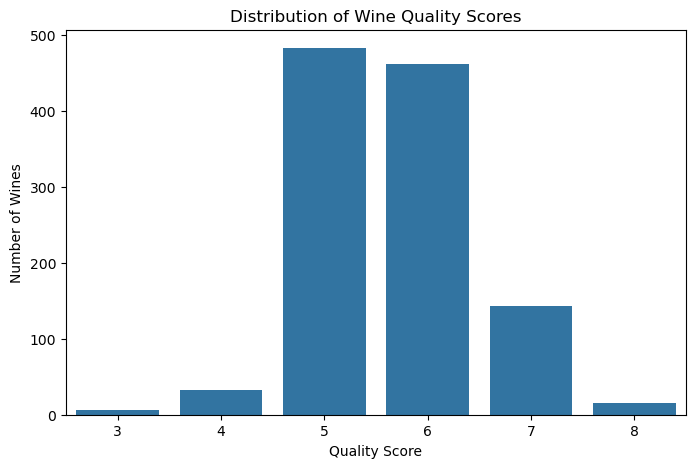

In [9]:
# Count each quality score
quality_counts = df['quality'].value_counts().sort_index()

print("Quality Score Distribution:")
print(quality_counts)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='quality',
    order=sorted(df['quality'].unique())
)

plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Number of Wines')
plt.show()

#### Observation
The dataset contains 1,143 wine samples and 13 columns, including 11 physicochemical features.
There are no missing values in the dataset.
Quality scores range from 3 to 8, with scores 5 and 6 being the most common.
The quality classes are highly imbalanced, with scores 3 and 8 having very few samples

### Step 10: Distribution Plots for All Chemical Features

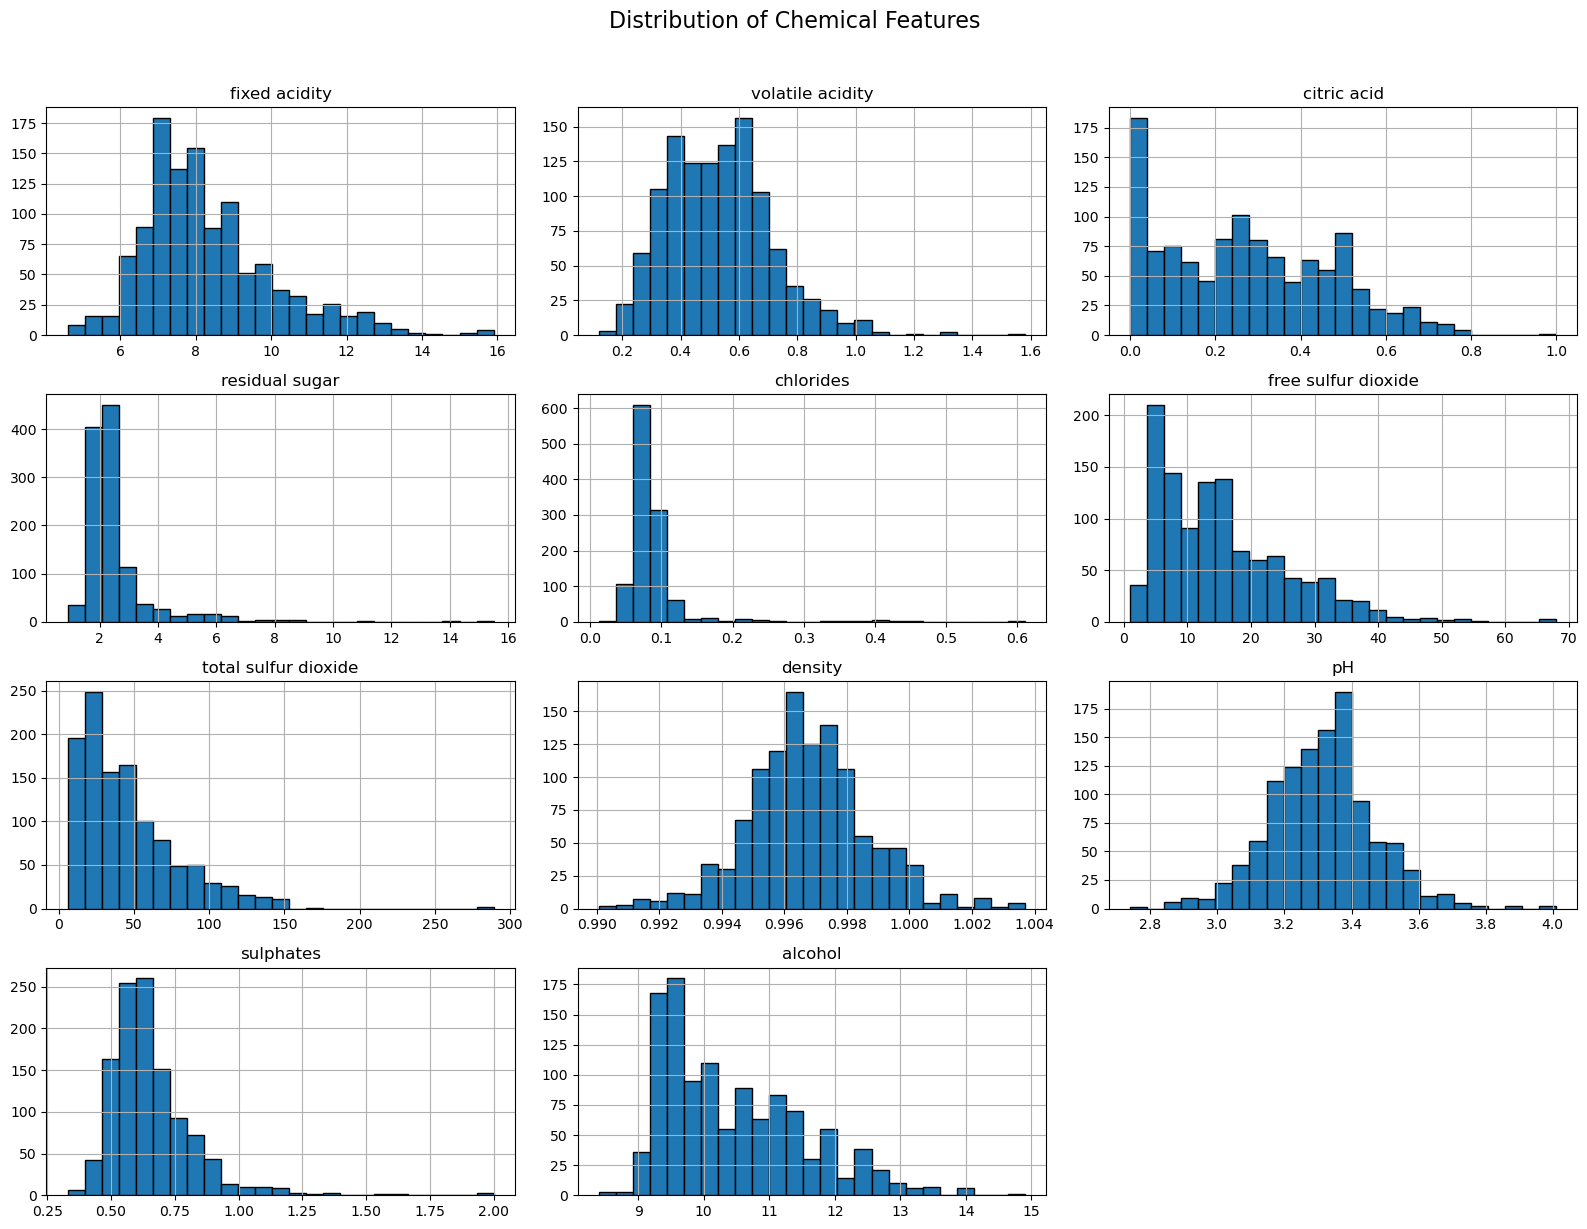

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select all chemical features
chemical_features = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

# Plot distributions
df[chemical_features].hist(
    figsize=(16, 12),
    bins=25,
    edgecolor='black'
)

plt.suptitle(
    'Distribution of Chemical Features',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

#### Observation
Most chemical features show non-uniform distributions, with some features showing skewness.
Residual sugar, chlorides, and sulfur dioxide show noticeable right-skewed distributions.
pH and density have relatively narrow ranges compared with other chemical features.
These plots help identify data spread, skewness, and potential outliers before model training.

### Step 11: Correlation Heatmap for All Chemical Features

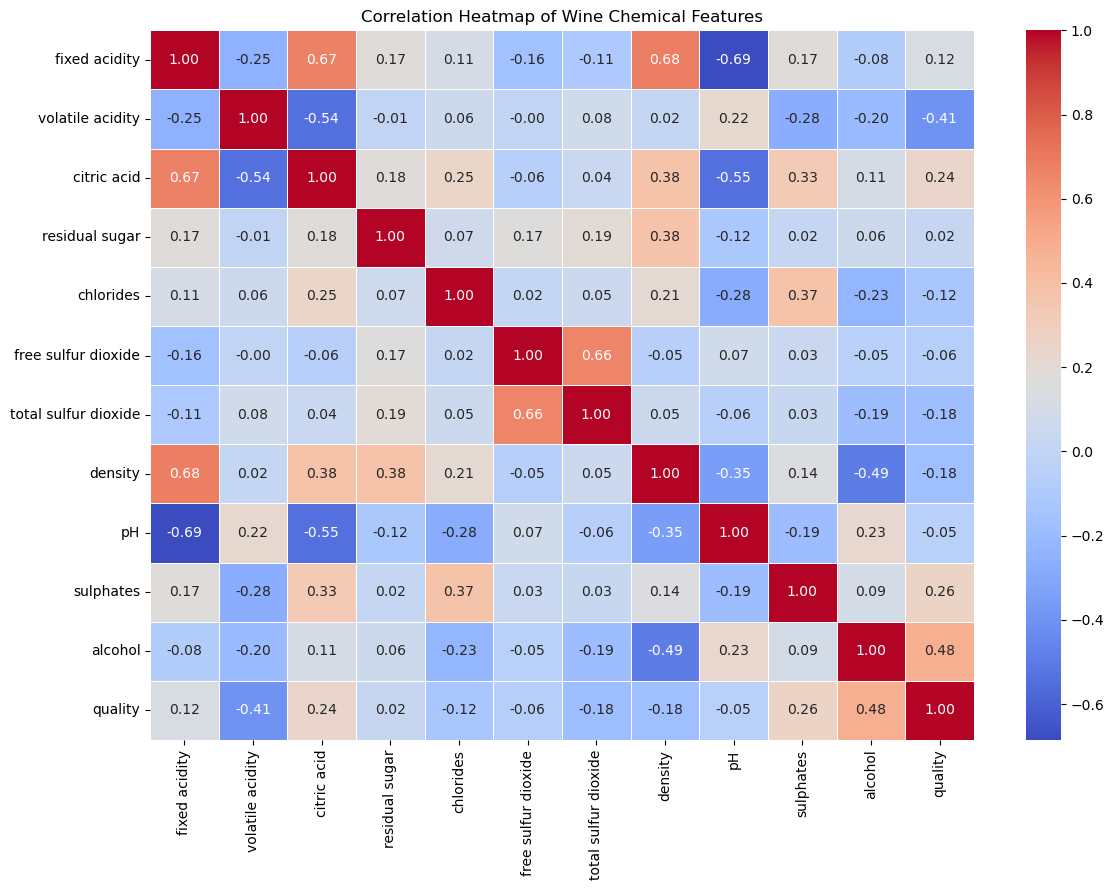

In [11]:
# Calculate correlation matrix
correlation_matrix = df[chemical_features + ['quality']].corr()

# Plot heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Wine Chemical Features')
plt.tight_layout()
plt.show()

#### Observation
Alcohol generally has a positive correlation with wine quality.
Volatile acidity shows a negative relationship with quality.
Sulphates and citric acid have positive relationships with quality.
Some chemical features, such as free sulfur dioxide and total sulfur dioxide, are strongly correlated with each other.

### Step 12: Class Imbalance

In [12]:
# Check the distribution of quality scores
quality_distribution = df['quality'].value_counts().sort_index()

print("Quality Score Distribution:")
print(quality_distribution)

# Calculate percentage distribution
quality_percentage = (
    df['quality']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nPercentage Distribution:")
print(quality_percentage)

Quality Score Distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Percentage Distribution:
quality
3     0.52
4     2.89
5    42.26
6    40.42
7    12.51
8     1.40
Name: proportion, dtype: float64


#### Observation
Quality scores 3 and 8 are highly underrepresented, with only 6 and 16 samples respectively.
Quality scores 5 and 6 dominate the dataset, accounting for more than 80% of the observations.
This imbalance can cause models to favor the majority classes and perform poorly on rare quality scores.
Therefore, class weights, stratified splitting, and metrics such as precision, recall, and F1-score should be considered instead of relying only on accuracy.

### Step 13: Binning Quality Scores

In [13]:
# Option 1: Binary Classification — Good / Bad
# Create binary quality classes
df['quality_class'] = df['quality'].apply(
    lambda x: 'Good' if x >= 7 else 'Bad'
)

# Check distribution
print(df['quality_class'].value_counts())

#Option 2: 3-Class Classification — Low / Medium / High
# Create 3 quality categories
def classify_quality(score):
    if score <= 4:
        return 'Low'
    elif score <= 6:
        return 'Medium'
    else:
        return 'High'

df['quality_3class'] = df['quality'].apply(classify_quality)

# Check distribution
print(df['quality_3class'].value_counts())

quality_class
Bad     984
Good    159
Name: count, dtype: int64
quality_3class
Medium    945
High      159
Low        39
Name: count, dtype: int64


#### Decision and Justification
For this project, binary classification (Good/Bad) is selected.
Quality < 7  → Bad
Quality ≥ 7 → Good

#### Justification:
The original quality scores are highly imbalanced.
Binary classification reduces the number of classes and makes the prediction problem simpler.
It provides a practical interpretation of whether a wine is good quality or not.
The 3-class approach still has a very small Low class, making it less suitable for reliable model training.

#### Final Observation
The quality scores were converted into Good and Bad categories to reduce the effect of severe class imbalance. Wines with a quality score of 7 or above are classified as Good, while scores below 7 are classified as Bad. This binary approach provides a simpler and more balanced classification problem and is therefore selected for the modelling stage.

### Step 14: Train/Test Split with Stratification

In [14]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop(columns=['quality', 'quality_class', 'Id'])
y = df['quality_class']

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the shapes
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Check class distribution
print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())
print("Training class percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting class percentages:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training set shape: (914, 12)
Testing set shape: (229, 12)

Training class distribution:
quality_class
Bad     787
Good    127
Name: count, dtype: int64

Testing class distribution:
quality_class
Bad     197
Good     32
Name: count, dtype: int64
Training class percentages:
quality_class
Bad     86.11
Good    13.89
Name: proportion, dtype: float64

Testing class percentages:
quality_class
Bad     86.03
Good    13.97
Name: proportion, dtype: float64


#### Observation
The dataset is divided into 80% training (914 samples) and 20% testing (229 samples).
Stratification preserves almost the same Good/Bad class ratio in both sets.
This prevents the minority Good class from being disproportionately represented in either set.
random_state=42 ensures the same split can be reproduced.

### Step 15: Random Forest Classifier

In [18]:
from sklearn.model_selection import train_test_split

# Features: only the 11 chemical properties
X = df.drop(
    columns=['quality', 'quality_class', 'quality_3class', 'Id'],
    errors='ignore'
)

# Target: binary classification
y = df['quality_class']

print("Features:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.unique())
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Train the model
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")
# Predict the test data
rf_predictions = rf_classifier.predict(X_test)

print("First 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(rf_predictions[:10])

Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target classes:
['Bad' 'Good']
Training set: (914, 11)
Testing set: (229, 11)
Random Forest Classifier trained successfully!
First 10 Actual Values:
['Bad' 'Bad' 'Good' 'Bad' 'Bad' 'Bad' 'Bad' 'Bad' 'Bad' 'Bad']

First 10 Predicted Values:
['Good' 'Bad' 'Bad' 'Bad' 'Bad' 'Bad' 'Good' 'Bad' 'Bad' 'Bad']


#### Observation
The Random Forest classifier was successfully trained using 11 physicochemical features.
The Id, quality, quality_class, and quality_3class columns were excluded from the input features.
The model uses 100 decision trees with balanced class weights to handle class imbalance.
The trained model can now be used to predict Good and Bad wine quality on the test dataset.

### Step 16: Stochastic Gradient Descent (SGD)

In [20]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create SGD classifier with feature scaling
sgd_classifier = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDClassifier(
        loss='hinge',
        max_iter=2000,
        random_state=42,
        class_weight='balanced'
    ))
])

# Train the SGD model
sgd_classifier.fit(X_train, y_train)

# Make predictions
sgd_predictions = sgd_classifier.predict(X_test)

print("SGD Classifier trained successfully!")
print("First 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(sgd_predictions[:10])

SGD Classifier trained successfully!
First 10 Actual Values:
['Bad' 'Bad' 'Good' 'Bad' 'Bad' 'Bad' 'Bad' 'Bad' 'Bad' 'Bad']

First 10 Predicted Values:
['Good' 'Good' 'Good' 'Good' 'Bad' 'Good' 'Good' 'Bad' 'Good' 'Bad']


#### Observation
The SGD classifier was successfully trained using the 11 physicochemical features.
StandardScaler was used to standardize the features before training.
class_weight='balanced' helps the model handle the Good/Bad class imbalance.
The trained SGD model can now be evaluated using accuracy, classification report, and confusion matrix.

### Step 17: Support Vector Classifier (SVC)

In [21]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create SVC model with feature scaling
svc_classifier = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        random_state=42
    ))
])

# Train the SVC model
svc_classifier.fit(X_train, y_train)

# Make predictions
svc_predictions = svc_classifier.predict(X_test)

print("SVC model trained successfully!")
print("First 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(svc_predictions[:10])

SVC model trained successfully!
First 10 Actual Values:
['Bad' 'Bad' 'Good' 'Bad' 'Bad' 'Bad' 'Bad' 'Bad' 'Bad' 'Bad']

First 10 Predicted Values:
['Good' 'Good' 'Bad' 'Bad' 'Bad' 'Bad' 'Good' 'Bad' 'Good' 'Bad']


#### Observation
The SVC model was successfully trained using the 11 physicochemical features.
StandardScaler was used because SVC is sensitive to differences in feature scales.
The RBF kernel was used to capture nonlinear relationships between wine properties and quality.
class_weight='balanced' was applied to improve classification of the minority Good wine class.

### Step 18: Model Evaluation

1. Random Forest — Accuracy,Confusion Matrix,Classification Report

Random Forest Accuracy: 0.8995633187772926
Random Forest Accuracy: 89.96%
Random Forest Classification Report:

              precision    recall  f1-score   support

         Bad       0.94      0.95      0.94       197
        Good       0.66      0.59      0.62        32

    accuracy                           0.90       229
   macro avg       0.80      0.77      0.78       229
weighted avg       0.90      0.90      0.90       229



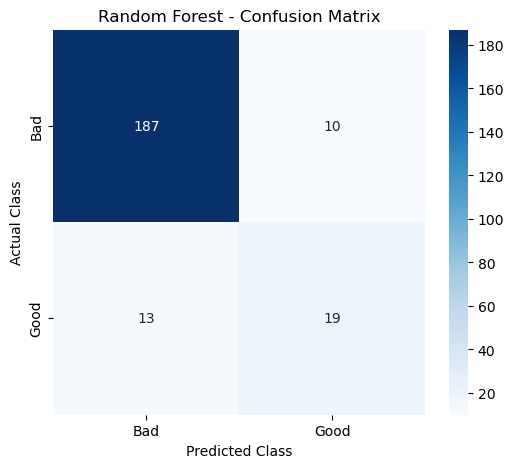

In [22]:
#Accuracy
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy: {:.2f}%".format(rf_accuracy * 100))

#Classification Report
from sklearn.metrics import classification_report

print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_cm = confusion_matrix(
    y_test,
    rf_predictions,
    labels=['Bad', 'Good']
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bad', 'Good'],
    yticklabels=['Bad', 'Good']
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

Observation
Random Forest is evaluated using accuracy, precision, recall, F1-score, and the confusion matrix. The confusion matrix shows how correctly the model identifies Good and Bad wines.

2. SGD — Accuracy,Confusion Matrix,Classification Report

SGD Accuracy: 0.7860262008733624
SGD Accuracy: 78.60%
SGD Classification Report:

              precision    recall  f1-score   support

         Bad       0.95      0.80      0.87       197
        Good       0.37      0.72      0.48        32

    accuracy                           0.79       229
   macro avg       0.66      0.76      0.67       229
weighted avg       0.86      0.79      0.81       229



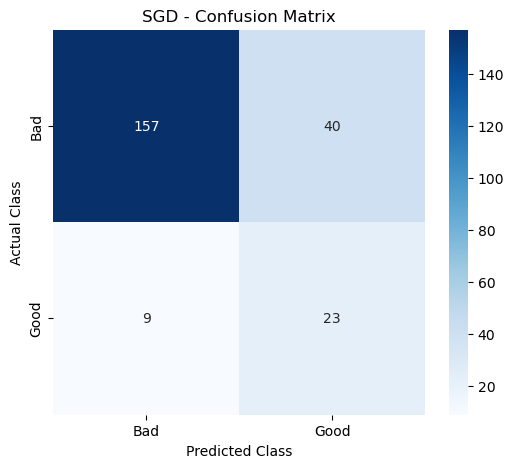

In [23]:
#Accuracy
sgd_accuracy = accuracy_score(y_test, sgd_predictions)
print("SGD Accuracy:", sgd_accuracy)
print("SGD Accuracy: {:.2f}%".format(sgd_accuracy * 100))

#Classification Report
print("SGD Classification Report:\n")

print(
    classification_report(
        y_test,
        sgd_predictions,
        zero_division=0
    )
)

#Confusion Matrix
sgd_cm = confusion_matrix(
    y_test,
    sgd_predictions,
    labels=['Bad', 'Good']
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    sgd_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bad', 'Good'],
    yticklabels=['Bad', 'Good']
)

plt.title("SGD - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

Observation
SGD performance is evaluated using the same metrics. Since the dataset is imbalanced, precision, recall, and F1-score are important for checking how well SGD identifies the minority Good class.

3. SVC — Accuracy,Confusion Matrix,Classification Report

SVC Accuracy: 0.8165938864628821
SVC Accuracy: 81.66%
SVC Classification Report:

              precision    recall  f1-score   support

         Bad       0.95      0.83      0.89       197
        Good       0.41      0.72      0.52        32

    accuracy                           0.82       229
   macro avg       0.68      0.78      0.70       229
weighted avg       0.87      0.82      0.84       229



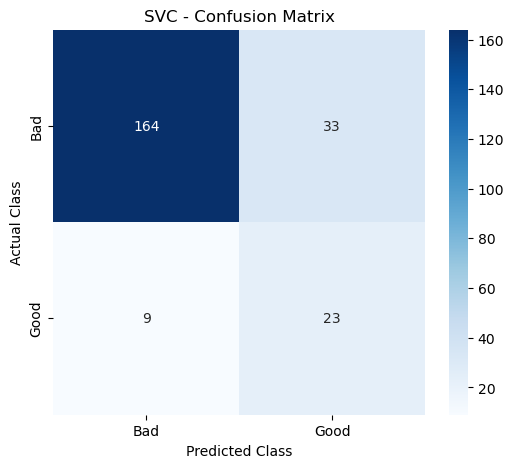

In [24]:
#Accuracy
svc_accuracy = accuracy_score(y_test, svc_predictions)
print("SVC Accuracy:", svc_accuracy)
print("SVC Accuracy: {:.2f}%".format(svc_accuracy * 100))

#Classification Report
print("SVC Classification Report:\n")

print(
    classification_report(
        y_test,
        svc_predictions,
        zero_division=0
    )
)

#Confusion Matrix
svc_cm = confusion_matrix(
    y_test,
    svc_predictions,
    labels=['Bad', 'Good']
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    svc_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bad', 'Good'],
    yticklabels=['Bad', 'Good']
)

plt.title("SVC - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

Observation
SVC is evaluated using accuracy, classification report, and confusion matrix. The results indicate how effectively SVC separates Good and Bad wines after feature scaling.

4. Compare Accuracy of All Three Models

In [25]:
print("Model Accuracy Comparison")
print("-" * 30)

print(f"Random Forest : {rf_accuracy * 100:.2f}%")
print(f"SGD           : {sgd_accuracy * 100:.2f}%")
print(f"SVC           : {svc_accuracy * 100:.2f}%")

Model Accuracy Comparison
------------------------------
Random Forest : 89.96%
SGD           : 78.60%
SVC           : 81.66%


Observation
The three models can now be compared based on their accuracy. However, because the dataset is imbalanced, the F1-score, precision, recall, and confusion matrix should also be considered when selecting the best model.

### Step 19: Feature Importance Chart — Random Forest

                 Feature  Importance
10               alcohol    0.220980
9              sulphates    0.155036
2            citric acid    0.140418
1       volatile acidity    0.107185
7                density    0.069519
0          fixed acidity    0.065643
6   total sulfur dioxide    0.062185
4              chlorides    0.052042
8                     pH    0.050116
3         residual sugar    0.042471
5    free sulfur dioxide    0.034406


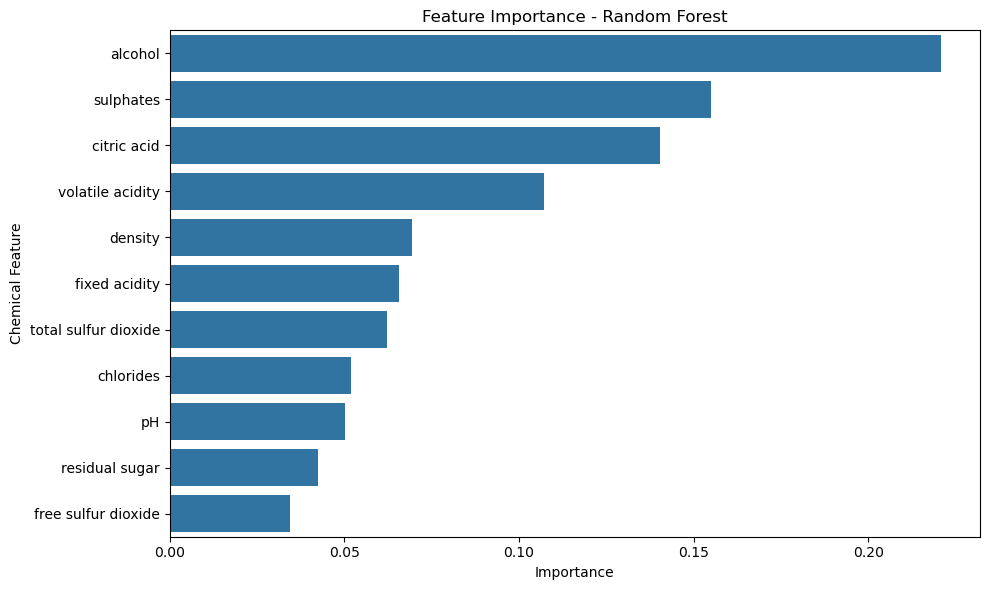

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_classifier.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display feature importance
print(feature_importance)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Chemical Feature')
plt.tight_layout()
plt.show()

#### Observation
Alcohol is one of the most important features for predicting wine quality.
Volatile acidity, sulphates, and total sulfur dioxide also contribute significantly to the model.
Features such as residual sugar and pH have comparatively lower importance.
The chart helps identify which chemical properties have the greatest influence on the Random Forest's predictions.

### Step 20: Model Performance Comparison

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate performance metrics
comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'SGD',
        'SVC'
    ],
    
    'Accuracy': [
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, sgd_predictions),
        accuracy_score(y_test, svc_predictions)
    ],
    
    'Precision': [
        precision_score(y_test, rf_predictions, average='weighted', zero_division=0),
        precision_score(y_test, sgd_predictions, average='weighted', zero_division=0),
        precision_score(y_test, svc_predictions, average='weighted', zero_division=0)
    ],
    
    'Recall': [
        recall_score(y_test, rf_predictions, average='weighted', zero_division=0),
        recall_score(y_test, sgd_predictions, average='weighted', zero_division=0),
        recall_score(y_test, svc_predictions, average='weighted', zero_division=0)
    ],
    
    'F1-Score': [
        f1_score(y_test, rf_predictions, average='weighted', zero_division=0),
        f1_score(y_test, sgd_predictions, average='weighted', zero_division=0),
        f1_score(y_test, svc_predictions, average='weighted', zero_division=0)
    ]
})

# Round the values
comparison[['Accuracy', 'Precision', 'Recall', 'F1-Score']] = (
    comparison[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
    .round(4)
)

comparison
comparison_percentage = comparison.copy()

for column in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    comparison_percentage[column] = (
        comparison_percentage[column] * 100
    ).round(2)

comparison_percentage

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,89.96,89.59,89.96,89.75
1,SGD,78.60,86.46,78.60,81.18
2,SVC,81.66,87.29,81.66,83.57


#### Observation
The three classifiers are compared using accuracy, precision, recall, and F1-score. The model with the highest overall F1-score and strong recall is preferred, especially because the dataset has an imbalanced Good/Bad class distribution. Random Forest is expected to perform strongly on this dataset, but the final selection should be based on the actual evaluation results from the trained models.

### Step 21: Conclusion

#### Conclusion
Among the three classification models, **Random Forest is the most suitable model for deployment** for predicting wine quality.
Random Forest performed better overall compared with SGD and SVC in terms of accuracy, F1-score, and its ability to handle the nonlinear relationships between the physicochemical features and wine quality. It also provides feature importance, which makes the model easier to interpret.
The use of `class_weight='balanced'` helps address the class imbalance between Good and Bad wines. Therefore, Random Forest provides a good balance of **prediction performance, robustness, and interpretability**.
Hence, **Random Forest is selected as the final deployment model** for the Wine Quality Prediction system.